<a href="https://colab.research.google.com/github/Herpsime/gdsc_study_session_ML_g1/blob/main/news_neural_net/notebook/FakeNews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip install kaggle torch scikit-learn pandas numpy matplotlib

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [23]:
import torch
import torch.nn as nn
import torchvision
import torch.optim as optim
import torchvision.transforms as transforms

In [24]:
url = 'https://raw.githubusercontent.com/lutzhamel/fake-news/master/data/fake_or_real_news.csv'

In [25]:
data = pd.read_csv(url)
data = data[['title', 'label']].dropna()
data['label'] = data['label'].map({'FAKE': 1, 'REAL': 0}).astype(np.float32)

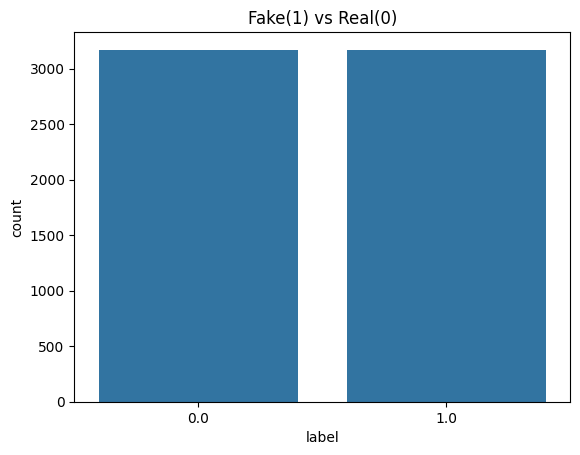

In [29]:
data.shape
data['label'].value_counts()
sns.countplot(x='label', data=data)
plt.title('Fake(1) vs Real(0)')
plt.show()

In [30]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(data['title']).toarray()
y = data['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (5068, 5000), Test: (1267, 5000)


In [31]:
from torch.utils.data import Dataset, DataLoader, TensorDataset

In [32]:
transform = transforms.ToTensor()

train_dataset= torchvision.datasets.MNIST(
    root = "./data",
    train= True,
    download= True,
    transform = transform
)
test_dataset= torchvision.datasets.MNIST(
    root = "./data",
    train= False,
    transform = transform
)



train_loader = torch.utils.data.DataLoader(
    dataset = train_dataset,
    batch_size = 64,
    shuffle = True
)
teat_loader = torch.utils.data.DataLoader(
    dataset = test_dataset,
    batch_size = 64,
)

In [33]:
class FakeNewsNet(nn.Module):
    def __init__(self, input_size):
        super(FakeNewsNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


X = data['title']
y = data['label']

vectorizer = TfidfVectorizer(max_features=5000)
X_vectorized = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)


input_size = X_train.shape[1]
model = FakeNewsNet(input_size)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(input_size)
sum(p.numel() for p in model.parameters())

5000


648449